<a href="https://colab.research.google.com/github/Harshmahajann/Machine_Learning_Practicals/blob/main/Lab_02_ML_Generalization_and_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<i>(c) 2026. Created by Mohammad M. Ajallooeian.</i>

---

**Important Note**:

Please do not alter any part of this notebook outside the designated text cells that are clearly marked with "*Start student input* ↓" and "*End student input ↑*". Changes made outside these specified areas could lead to incorrect evaluations of your work, potentially affecting your lab scores.

Ensure you complete all activities within these sections, which are indicated by labels like **[A1]**, **[A2]**, **[A3]**, ... Each activity is crucial for the successful completion of this lab. Additionally, please name your variables exactly as specified in the instructions (if specified) to ensure that your answers are correctly assessed.

Make sure to fill your name in the box below. Also modify the file name so reflect your name inside the parentheses. For example, if this file is named `Lab x - Topic (Student).ipynb` rename it to `Lab x - Topic (First Last).ipynb` where `First` is your first name and `Last` is your last name.

---

**Student name**: Harsh Mahajan

**Math display note**: If you are on a mac, for math to display correctly, you need to update MathJax's parameters. Create a new bookmark and put this code:
```
javascript:(function(){if(window.MathJax&&MathJax.Hub&&MathJax.Hub.Queue){MathJax.Hub.Queue(["setRenderer",MathJax.Hub,"CommonHTML"]);MathJax.Hub.Queue(["Rerender",MathJax.Hub]);}else{alert("MathJax v2 (Hub) not found on this page.");}})();
```
as the URL and give it whatever name you like (for example "Math Display"). Then execute the bookmark while on the browser tab containing the notebook.

# Lab 02: ML Generalization and Model Evaluation

## Marking rubric

| Activity | Topic | Marks |
|----------|-------|-------|
| A1 | Data Exploration (EDA) | **Not graded** (required) |
| A2 | Building a Baseline k-NN Classifier | 15 marks |
| A3 | Experimenting with Distance Metrics | 15 marks |
| A4 | Evaluation Metrics | 25 marks |
| A5 | Hyperparameter Tuning and Generalization | 25 marks |
| A6 | Discussion Questions | 20 marks |
| | **Total** | **100 marks** |

## Learning Objectives

By the end of this lab, you will be able to:

1. **Work with real-world data** by loading datasets from Kaggle, the world's largest data science community.
2. **Perform exploratory data analysis (EDA)** to understand your data before modeling.
3. **Build and train k-NN classifiers** using scikit-learn with different configurations.
4. **Apply different distance metrics** (Euclidean, Manhattan, Chebyshev) and understand when to use each.
5. **Evaluate classification models** using metrics beyond accuracy: precision, recall, F1 score, and confusion matrices.
6. **Identify and diagnose overfitting and underfitting** by analyzing training vs. test performance.
7. **Tune hyperparameters** systematically using validation loops.
8. **Recognize the importance of feature scaling** for distance-based algorithms.

## Why This Lab Matters: The Central Challenge of Machine Learning

Imagine you're studying for an exam. You could:

1. **Memorize every practice question word-for-word** — You'd ace those exact questions, but struggle with anything slightly different.
2. **Never study at all** — You'd fail everything.
3. **Understand the underlying concepts** — You'd handle both familiar and new questions well.

Machine learning faces the same challenge:

- **Overfitting** = Memorizing the training data (like option 1)
- **Underfitting** = Not learning enough (like option 2)  
- **Good generalization** = Learning patterns that transfer to new data (like option 3)

**This is THE central challenge of machine learning.** A model that only works on training data is useless in the real world. Throughout this course—and your ML career—you'll constantly work to find models that generalize well.

In this lab, we'll make these concepts concrete by:
- Watching overfitting happen in real-time
- Learning to diagnose it with proper evaluation
- Understanding how hyperparameters control the overfitting/underfitting tradeoff

---

## 🚀 Building Your Data Science Career: A Note on Professional Development

Before we dive into the technical content, let's talk about something equally important: **building your professional presence**. The skills you're learning in this course are in high demand, but technical skills alone don't get you hired—you need to demonstrate them.

### Kaggle: More Than Just Datasets

In this lab, we'll download data from **[Kaggle](https://www.kaggle.com/)**. But Kaggle is much more than a data repository—it's the world's largest community of data scientists and machine learners, with over 15 million users.

**What Kaggle offers:**

| Feature | Why It Matters |
|---------|----------------|
| **Competitions** | Real problems from real companies (Google, Microsoft, etc.) with cash prizes. Even participating without winning shows initiative. |
| **Datasets** | Thousands of free, curated datasets for practice and projects. |
| **Notebooks** | Free cloud computing environment (like Colab) where you can share your work publicly. |
| **Discussions** | Learn from experts, ask questions, and help others—all visible to potential employers. |
| **Rankings & Titles** | Earn titles (Novice → Contributor → Expert → Master → Grandmaster) that employers recognize. |

**Career tip:** Many hiring managers look at Kaggle profiles. A candidate with a "Notebooks Expert" title or competition medals immediately stands out.

### Building Your Professional Portfolio

As you progress through this course and your studies, actively build your online presence:

**1. GitHub** (https://github.com)
- Host your code projects with clear README files
- Contribute to open-source projects
- Show consistent activity (the "green squares" matter!)
- *Tip: Quality over quantity—a few well-documented projects beat dozens of empty repos*

**2. LinkedIn** (https://linkedin.com)
- Keep your profile updated with skills and projects
- Share your learning journey ("Just completed a project on...")
- Connect with classmates, professors, and industry professionals
- Follow companies and thought leaders in AI/ML
- *Tip: Recruiters search by keywords—include terms like "machine learning", "Python", "scikit-learn"*

**3. Kaggle** (https://kaggle.com)
- Complete your profile
- Publish notebooks from your course projects (cleaned up and well-commented)
- Participate in competitions—even just submitting a baseline shows engagement
- *Tip: Start with "Getting Started" competitions designed for beginners*

**4. Personal Website/Blog** (optional but powerful)
- Write about what you're learning
- Explain concepts in your own words
- Document your projects with context and results

### The Portfolio Mindset

Every assignment, project, and lab is potential portfolio material. As you work through this course:

- **Save your best work** in a dedicated folder
- **Add comments** explaining your thought process
- **Clean up code** before making it public
- **Document results** with visualizations and explanations

When you apply for jobs or internships, you'll have concrete evidence of your skills rather than just listing "Python" and "Machine Learning" on a resume.

**Now, let's build something worth adding to that portfolio!**

---

## 0. Setup and Environment Configuration

Let's set up our working environment. We'll install necessary packages and configure Kaggle access to download our dataset.

### 0.1 Environment Detection

This notebook is designed to run on both **Google Colab** and **local Jupyter environments**. The following cell detects which environment you're using.

In [1]:
# Detect if we're running on Google Colab
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("✓ Running on Google Colab")
    print("  - Free GPU/TPU available (Runtime → Change runtime type)")
    print("  - Files are temporary unless saved to Google Drive")
else:
    print("✓ Running on local Jupyter environment")
    print("  - Files persist in your local directory")

✓ Running on Google Colab
  - Free GPU/TPU available (Runtime → Change runtime type)
  - Files are temporary unless saved to Google Drive


### 0.2 Install Required Packages

We need the `kagglehub` package to download datasets from Kaggle. This package handles authentication and downloading seamlessly.

In [2]:
# Install kagglehub for dataset downloading
!pip install -q kagglehub

print("✓ Packages installed successfully")

✓ Packages installed successfully


### 0.3 Import Libraries

Let's import all the libraries we'll need. Take a moment to read the comments—understanding what each library does is part of becoming a proficient data scientist.

In [3]:
# ============================================================
# STANDARD LIBRARIES
# ============================================================
import os                    # Operating system interface (file paths, etc.)
import warnings              # Control warning messages
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# ============================================================
# DATA MANIPULATION
# ============================================================
import numpy as np           # Numerical computing (arrays, linear algebra)
import pandas as pd          # Data manipulation and analysis (DataFrames)

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Statistical visualization (prettier than matplotlib)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ============================================================
# MACHINE LEARNING (scikit-learn)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier    # Our main algorithm
from sklearn.model_selection import train_test_split  # Split data into train/test

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,           # (Correct predictions) / (Total predictions)
    precision_score,          # TP / (TP + FP) - "Of predicted positives, how many correct?"
    recall_score,             # TP / (TP + FN) - "Of actual positives, how many found?"
    f1_score,                 # Harmonic mean of precision and recall
    confusion_matrix,         # Matrix showing TP, TN, FP, FN
    ConfusionMatrixDisplay    # Visualization for confusion matrix
)

# ============================================================
# KAGGLE DATASET ACCESS
# ============================================================
import kagglehub              # Download datasets from Kaggle

# ============================================================
# DISPLAY SETTINGS
# ============================================================
pd.set_option('display.max_columns', None)      # Show all columns
pd.set_option('display.width', None)            # Don't wrap wide DataFrames
np.set_printoptions(precision=4, suppress=True) # Cleaner numpy output

print("✓ All libraries imported successfully")
print(f"  - NumPy version: {np.__version__}")
print(f"  - Pandas version: {pd.__version__}")

✓ All libraries imported successfully
  - NumPy version: 2.1.3
  - Pandas version: 2.2.3


### 0.4 Kaggle API Configuration

To download datasets from Kaggle, you need to authenticate with their API. Kaggle now uses **API Tokens** (the recommended method).

#### Step-by-Step Instructions:

1. **Create a Kaggle account** (if you don't have one): Go to [kaggle.com](https://www.kaggle.com/) and sign up. *This is your first step toward building your data science portfolio!*

2. **Get your API Token**:
   - Click on your profile picture (top right) → **Settings**
   - Scroll down to the **API** section
   - Under **API Tokens (Recommended)**, click **"Generate New Token"**
   - Give it a name (e.g., "ML Course") and click **Generate**
   - **Important:** Copy the token immediately! It will only be shown once.

3. **Enter your credentials** in the cell below when prompted

**Security notes:**
- Your token is like a password—don't share it or commit it to public repositories!
- The token is stored only in memory during this session, NOT saved in the notebook
- When you submit your completed lab, your credentials will NOT be included

In [4]:
# ============================================================
# KAGGLE AUTHENTICATION (Token-based method)
# ============================================================
# This uses the new API Token system (recommended by Kaggle)
# Your credentials are stored in memory only - NOT saved to the notebook

import getpass

# Check if credentials are already set in environment
if os.environ.get('harshmhj') and os.environ.get('KGAT_c0c4ee37782d3e2654c9da355f49f07c'):
    print("✓ Kaggle credentials already configured")
else:
    print("Enter your Kaggle credentials:")
    print("(Get them from kaggle.com → Settings → API → Generate New Token)\n")

    # Get username
    kaggle_username = input("Kaggle Username: ").strip()

    # Get API token (hidden input for security)
    kaggle_token = getpass.getpass("Kaggle API Token (hidden): ").strip()

    # Set environment variables (this is how kagglehub authenticates)
    os.environ['KAGGLE_USERNAME'] = kaggle_username
    os.environ['KAGGLE_KEY'] = kaggle_token

    print("\n✓ Kaggle credentials configured for this session")
    print("  (Credentials are in memory only - not saved to notebook)")

Enter your Kaggle credentials:
(Get them from kaggle.com → Settings → API → Generate New Token)

Kaggle Username: harshmhj
Kaggle API Token (hidden): ··········

✓ Kaggle credentials configured for this session
  (Credentials are in memory only - not saved to notebook)


### 0.5 Download the Dataset

We'll use the **Red Wine Quality** dataset from Kaggle. This dataset is originally from the UCI Machine Learning Repository and contains physicochemical properties of Portuguese red wines along with quality ratings.

**Dataset details:**
- **Source:** P. Cortez et al., "Modeling wine preferences by data mining from physicochemical properties" (2009)
- **Samples:** 1,599 red wine samples
- **Features:** 11 physicochemical measurements
- **Target:** Quality rating (0-10 scale)

**Why this dataset for learning k-NN?**

1. **Different feature scales** — Features range from 0.001 to 300+, perfect for understanding why normalization matters
2. **Real-world messiness** — Not perfectly separable classes, just like real problems
3. **Class imbalance** — Most wines are "average," few are "excellent" or "poor"

In [5]:
# Download the Wine Quality dataset from Kaggle
print("Downloading dataset from Kaggle...")
print("(This may take a moment on first run)\n")

try:
    # Download using kagglehub
    dataset_path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
    print(f"✓ Dataset downloaded to: {dataset_path}")

    # Load into pandas DataFrame
    csv_path = os.path.join(dataset_path, "winequality-red.csv")
    df = pd.read_csv(csv_path)
    print(f"✓ Data loaded: {df.shape[0]} samples, {df.shape[1]} columns")

except Exception as e:
    print(f"⚠ Kaggle download failed: {e}")
    print("\nUsing alternative download method...")

    # Alternative: Download directly from UCI repository
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url, sep=';')
    print(f"✓ Data loaded from UCI repository: {df.shape[0]} samples, {df.shape[1]} columns")

(This may take a moment on first run)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
✓ Dataset downloaded to: /kaggle/input/red-wine-quality-cortez-et-al-2009
✓ Data loaded: 1599 samples, 12 columns


---

## 1. Exploratory Data Analysis (EDA)

**"Torture the data, and it will confess to anything."** — Ronald Coase

Before building any model, we must **understand our data**. Exploratory Data Analysis (EDA) is the process of investigating datasets to:

- Discover patterns and relationships
- Spot anomalies and outliers
- Check assumptions
- Identify potential problems (missing values, weird distributions, etc.)

Skipping EDA is like driving blindfolded—you might get somewhere, but probably not where you intended!

**Note:** This section is required but **not graded**. However, the insights you gain here are essential for understanding the rest of the lab.

### 1.1 First Look at the Data

Let's start with the basics: What does our data look like?

In [6]:
# Display the first few rows
print("First 5 rows of the dataset:")
print("=" * 80)
df.head()

First 5 rows of the dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
# Dataset structure and data types
print("Dataset Information:")
print("=" * 80)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### 1.2 Understanding the Features

Let's understand what each feature represents:

| Feature | Description | Unit | Typical Range |
|---------|-------------|------|---------------|
| `fixed acidity` | Non-volatile acids (mainly tartaric acid) | g/dm³ | 4-16 |
| `volatile acidity` | Acetic acid (vinegar taste at high levels) | g/dm³ | 0.1-1.6 |
| `citric acid` | Adds freshness and flavor | g/dm³ | 0-1 |
| `residual sugar` | Sugar remaining after fermentation | g/dm³ | 0.9-16 |
| `chlorides` | Salt content | g/dm³ | 0.01-0.6 |
| `free sulfur dioxide` | Free form of SO₂ (prevents microbial growth) | mg/dm³ | 1-72 |
| `total sulfur dioxide` | Total SO₂ (free + bound forms) | mg/dm³ | 6-289 |
| `density` | Mass per volume | g/cm³ | 0.99-1.00 |
| `pH` | Acidity level (lower = more acidic) | - | 2.7-4.0 |
| `sulphates` | Antimicrobial and antioxidant additive | g/dm³ | 0.3-2.0 |
| `alcohol` | Alcohol content | % vol | 8-15 |
| `quality` | **TARGET** - Sensory quality score | - | 3-8 (in data) |

**Notice something important:** The ranges are vastly different! `total sulfur dioxide` goes up to ~289, while `density` varies only between 0.99 and 1.00. This will matter for k-NN!

In [8]:
# Statistical summary
print("Statistical Summary:")
print("=" * 80)
df.describe().round(2)

Statistical Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


### 1.3 Visualizing Feature Scales

Let's visualize just how different these feature scales are. This is **crucial** for understanding a key challenge we'll face with k-NN.

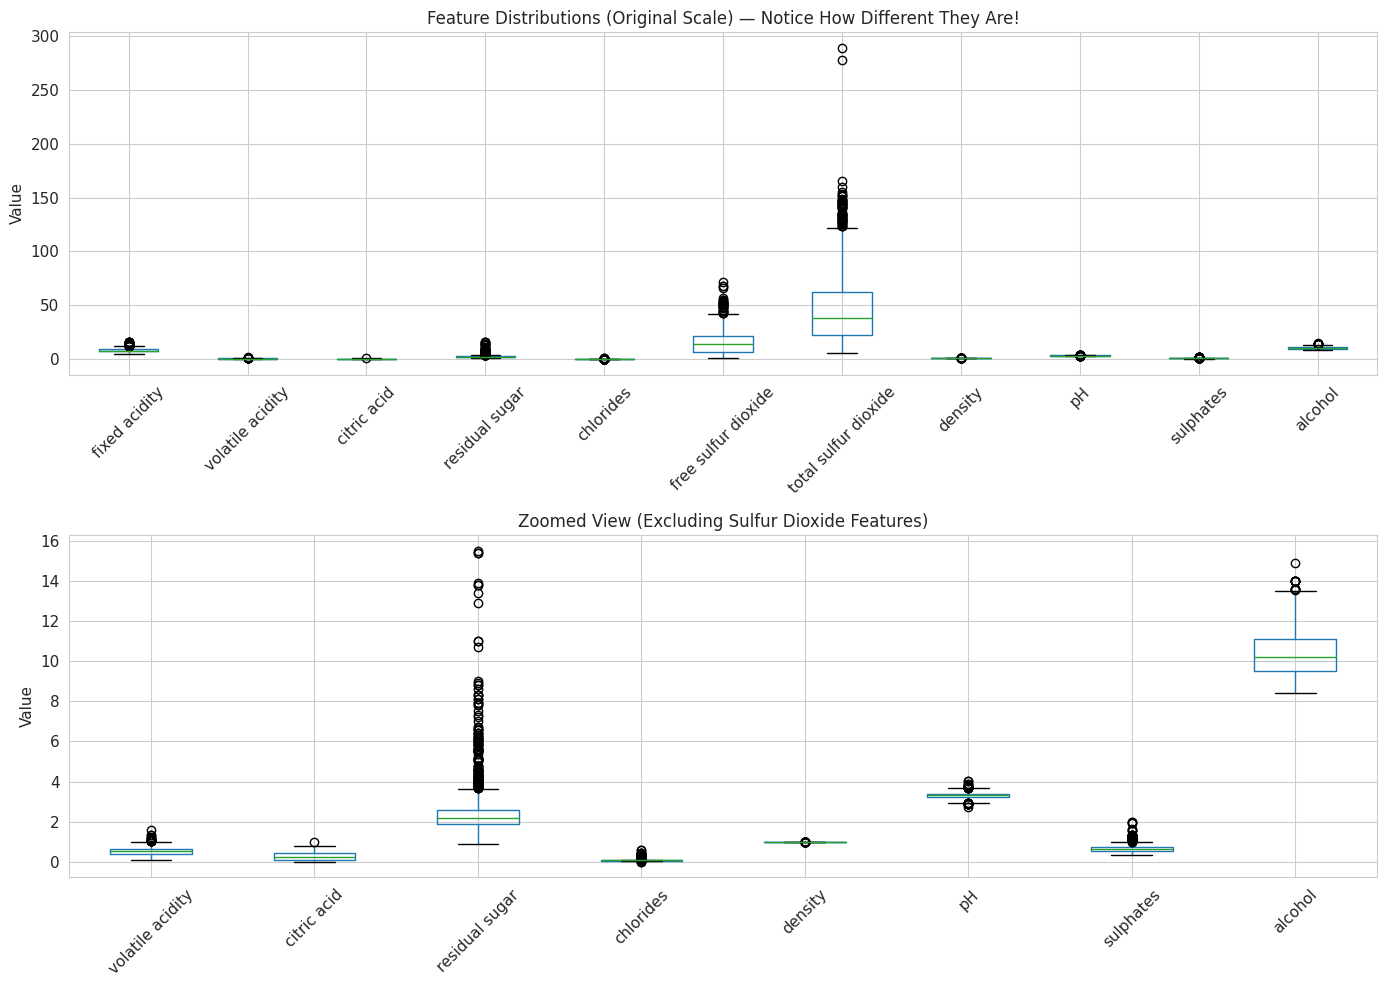

In [9]:
# Create boxplots to visualize feature distributions and scales
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top plot: All features (hard to see small-scale features)
df.drop('quality', axis=1).boxplot(ax=axes[0], rot=45)
axes[0].set_title('Feature Distributions (Original Scale) — Notice How Different They Are!', fontsize=12)
axes[0].set_ylabel('Value')

# Bottom plot: Zoomed in (excluding large-scale features)
small_scale_features = ['volatile acidity', 'citric acid', 'residual sugar',
                        'chlorides', 'density', 'pH', 'sulphates', 'alcohol']
df[small_scale_features].boxplot(ax=axes[1], rot=45)
axes[1].set_title('Zoomed View (Excluding Sulfur Dioxide Features)', fontsize=12)
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [ ]:
print("\n🔍 KEY OBSERVATION:")
print("   'total sulfur dioxide' ranges from ~6 to ~289")
print("   'citric acid' ranges from ~0 to ~1")
print("   That's a 289x difference in scale!")

### 1.4 The Target Variable: Wine Quality

Let's examine what we're trying to predict: wine quality ratings.

Quality Rating Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Total samples: 1599


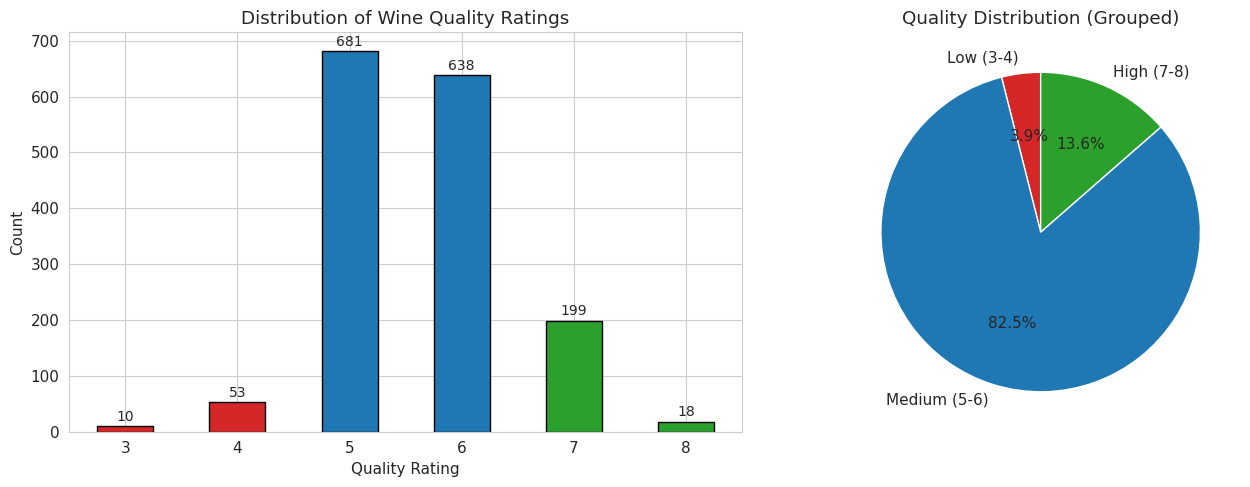

In [10]:
# Distribution of quality ratings
print("Quality Rating Distribution:")
print("=" * 40)
quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)
print(f"\nTotal samples: {len(df)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#d62728' if q < 5 else '#2ca02c' if q >= 7 else '#1f77b4'
          for q in quality_counts.index]
quality_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Wine Quality Ratings')
axes[0].set_xlabel('Quality Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, (idx, val) in enumerate(quality_counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=10)

# Pie chart showing imbalance
labels = ['Low (3-4)', 'Medium (5-6)', 'High (7-8)']
sizes = [
    quality_counts[quality_counts.index.isin([3, 4])].sum(),
    quality_counts[quality_counts.index.isin([5, 6])].sum(),
    quality_counts[quality_counts.index.isin([7, 8])].sum()
]
colors_pie = ['#d62728', '#1f77b4', '#2ca02c']
axes[1].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Quality Distribution (Grouped)')

plt.tight_layout()
plt.show()

In [11]:
print("\n🔍 KEY OBSERVATION:")
print("   Most wines are 'medium' quality (5-6)")
print("   Very few wines are 'high' quality (7-8)")
print("   This CLASS IMBALANCE will affect our evaluation!")


🔍 KEY OBSERVATION:
   Most wines are 'medium' quality (5-6)
   Very few wines are 'high' quality (7-8)
   This CLASS IMBALANCE will affect our evaluation!


### 1.5 Creating a Binary Classification Problem

For this lab, we'll simplify to a **binary classification** problem:
- **"Good" wine**: Quality ≥ 7 (labeled as 1)
- **"Not Good" wine**: Quality < 7 (labeled as 0)

**Why binary?**
1. Simpler to understand and visualize
2. Allows us to focus on key concepts (precision, recall, etc.)
3. Creates an interesting imbalanced classification problem

In [12]:
# Create binary target variable
df['good_quality'] = (df['quality'] >= 7).astype(int)

# Check the distribution
print("Binary Classification Distribution:")
print("=" * 40)
binary_counts = df['good_quality'].value_counts()
print(f"Not Good (0): {binary_counts[0]} ({100*binary_counts[0]/len(df):.1f}%)")
print(f"Good (1):     {binary_counts[1]} ({100*binary_counts[1]/len(df):.1f}%)")

Binary Classification Distribution:
Not Good (0): 1382 (86.4%)
Good (1):     217 (13.6%)


In [13]:
print("\n⚠️ CLASS IMBALANCE ALERT:")
print(f"   Only {100*binary_counts[1]/len(df):.1f}% of wines are 'Good'")
print("   A model that ALWAYS predicts 'Not Good' would be")
print(f"   {100*binary_counts[0]/len(df):.1f}% accurate! (But useless)")
print("   This is why we need metrics BEYOND accuracy.")


⚠️ CLASS IMBALANCE ALERT:
   Only 13.6% of wines are 'Good'
   A model that ALWAYS predicts 'Not Good' would be
   86.4% accurate! (But useless)
   This is why we need metrics BEYOND accuracy.


### 1.6 Preparing Features ($\mathbf{X}$) and Target ($\mathbf{y}$)

Let's separate our features from our target variable—the standard first step before modeling.

In [14]:
# Separate features and target
X = df.drop(['quality', 'good_quality'], axis=1)  # All columns except targets
y = df['good_quality']                             # Binary target

print("Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {list(X.columns)}")
print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Values: {y.unique()}")

Features (X):
  Shape: (1599, 11)
  Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target (y):
  Shape: (1599,)
  Values: [0 1]


---

##### **[A1] Data Exploration (EDA)** — Not Graded (but required)

Complete the following exploration tasks to deepen your understanding of the dataset. Even though this isn't graded, these skills are essential for any data science role!

Check if there are any missing values in the dataset. Use `.isnull()` method of pandas DataFrame objects and the `.sum()` method and print the count of missing values for each column.

*Start student input* ↓

In [15]:
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
good_quality            0
dtype: int64


*End student input* ↑

Create a correlation heatmap to visualize relationships between features. Use `seaborn.heatmap()` with the correlation matrix from `df.corr()`. Set `annot=True`, use the `'coolwarm'` colormap, and set `center=0` for better visualization.

*Start student input* ↓

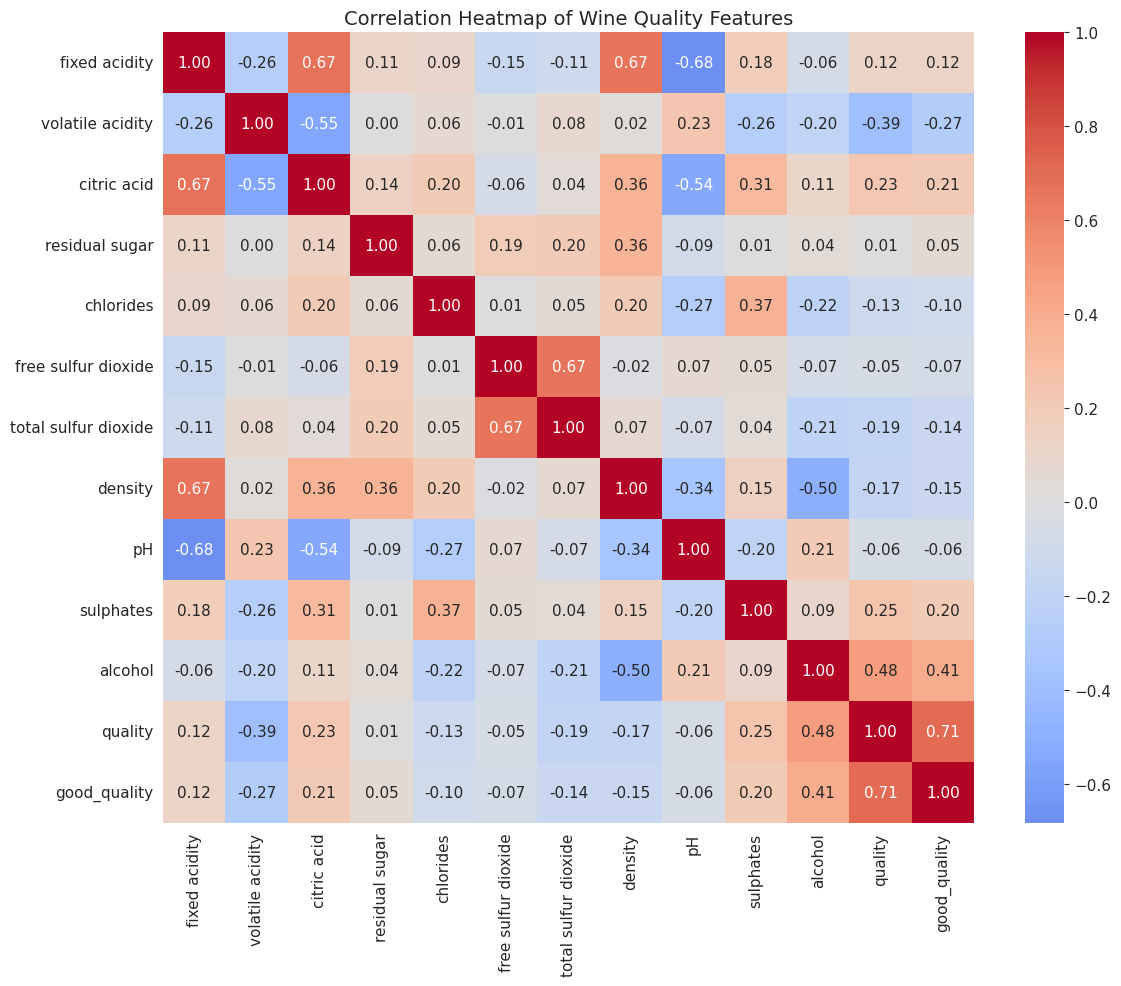

In [16]:
# Create a correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Wine Quality Features', fontsize=14)
plt.tight_layout()
plt.show()


*End student input* ↑

Based on the correlation heatmap, answer the following:
- Which feature has the **strongest positive correlation** with `quality`?
- Which feature has the **strongest negative correlation** with `quality`?
- Name two features that are **highly correlated with each other** (not with quality).

*Start student input* ↓


Based on the correlation heatmap: alcohol has the strongest positive correlation with quality, and volatile acidity has the strongest negative correlation with quality. Among features not involving quality, free sulfur dioxide and total sulfur dioxide are highly correlated with each other — which makes sense, since total SO₂ is defined as free SO₂ plus bound SO₂, so a higher free SO₂ pushes the total up. (Fixed acidity and pH also correlate strongly, since pH is a direct measure of acidity.)

*End student input* ↑

---

## 2. Building a Baseline k-NN Classifier

Now that we understand our data, let's build our first model! We'll follow the standard machine learning workflow:

1. **Split** the data into training and test sets
2. **Train** a model on the training data
3. **Predict** on the test data
4. **Evaluate** the model's performance

### 2.1 Why Split the Data?

Imagine a student who only studies by looking at the answer key. They might score 100% when tested on those exact questions, but fail miserably on new questions. This is **memorization**, not **learning**.

Similarly, if we train AND evaluate a model on the same data:
- The model might just "memorize" the training data
- We'd have no idea how it performs on new, unseen data
- We couldn't detect overfitting

**Solution:** Split data into:
- **Training set** (~80%): Used to train the model
- **Test set** (~20%): Held out, never seen during training, used only for final evaluation

This simulates how the model will perform "in the wild" on new data.

In [17]:
# Example: How train_test_split works
# Let's use a small example to illustrate

example_X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
example_y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    example_X, example_y,
    test_size=0.2,      # 20% for testing
    random_state=42     # For reproducibility
)

print("Original data: X =", example_X.flatten())
print("Original data: y =", example_y)
print()
print(f"Training set ({len(X_train_ex)} samples): X =", X_train_ex.flatten(), "y =", y_train_ex)
print(f"Test set ({len(X_test_ex)} samples):     X =", X_test_ex.flatten(), "y =", y_test_ex)
print()
print("Notice: The split is random (but reproducible with random_state=42)")

Original data: X = [ 1  2  3  4  5  6  7  8  9 10]
Original data: y = [0 0 0 0 0 1 1 1 1 1]

Training set (8 samples): X = [ 6  1  8  3 10  5  4  7] y = [1 0 1 0 1 0 0 1]
Test set (2 samples):     X = [9 2] y = [1 0]

Notice: The split is random (but reproducible with random_state=42)


### 2.2 Creating and Training a k-NN Classifier

scikit-learn provides a consistent API for all models:

```python
# 1. Create the model
model = SomeClassifier(hyperparameters)

# 2. Train (fit) the model
model.fit(X_train, y_train)

# 3. Make predictions
yhat = model.predict(X_test)

# 4. Evaluate
score = some_metric(y_test, yhat)
```

For k-NN, the key hyperparameter is `n_neighbors` (the value of k).

In [18]:
# Complete example with our wine data

# Step 1: Split the data
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {len(X_train_demo)} samples")
print(f"Test set: {len(X_test_demo)} samples")

# Step 2: Create and train k-NN classifier with k=5
knn_demo = KNeighborsClassifier(n_neighbors=5)
knn_demo.fit(X_train_demo, y_train_demo)
print(f"\nModel trained with k={knn_demo.n_neighbors}")

# Step 3: Make predictions
yhat_demo = knn_demo.predict(X_test_demo)
print(f"Predictions made for {len(yhat_demo)} test samples")

# Step 4: Evaluate
accuracy_demo = accuracy_score(y_test_demo, yhat_demo)
print(f"\nAccuracy: {accuracy_demo:.4f} ({accuracy_demo*100:.2f}%)")

Training set: 1279 samples
Test set: 320 samples

Model trained with k=5
Predictions made for 320 test samples

Accuracy: 0.8562 (85.62%)


---

##### **[A2] Building a Baseline k-NN Classifier** (15 marks)

Now it's your turn! Build a k-NN classifier following the steps demonstrated above.

**Your tasks:**
1. Split `X` and `y` into training and test sets (80%/20% split, `random_state=42`)
2. Create a k-NN classifier with `k=3`
3. Train the classifier on the training data
4. Make predictions on the test set
5. Calculate the accuracy

**Variable names to use:** `X_train`, `X_test`, `y_train`, `y_test`, `knn_baseline`, `yhat_baseline`, `accuracy_baseline`

In [19]:
# Initialize variables
X_train, X_test, y_train, y_test = None, None, None, None
knn_baseline = None
yhat_baseline = None
accuracy_baseline = 0

*Start student input* ↓

In [20]:
# Complete this.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Create the k-NN classifier with k=3
knn_baseline = KNeighborsClassifier(n_neighbors=3)

# Step 3: Train the classifier
knn_baseline.fit(X_train, y_train)

# Step 4: Make predictions on the test set
yhat_baseline = knn_baseline.predict(X_test)

# Step 5: Calculate accuracy
accuracy_baseline = accuracy_score(y_test, yhat_baseline)


*End student input* ↑

In [21]:
print(f"Baseline k-NN Accuracy (k=3): {accuracy_baseline:.4f}")

Baseline k-NN Accuracy (k=3): 0.8500


In [22]:
# Verification cell
print("=" * 50)
print("VERIFICATION")
print("=" * 50)
print(f"Training set size: {len(X_train) if X_train is not None else 'Not set'}")
print(f"Test set size: {len(X_test) if X_test is not None else 'Not set'}")
print(f"Model k value: {knn_baseline.n_neighbors if knn_baseline else 'Not set'}")
print(f"Number of predictions: {len(yhat_baseline) if yhat_baseline is not None else 'Not set'}")
print(f"Accuracy: {accuracy_baseline:.4f}")
print("=" * 50)

VERIFICATION
Training set size: 1279
Test set size: 320
Model k value: 3
Number of predictions: 320
Accuracy: 0.8500


---

## 3. Distance Metrics: How k-NN Measures "Nearness"

k-NN's core idea is: **"similar inputs have similar outputs."** But how do we measure similarity? Through **distance**—points that are "close" are considered similar.

The choice of distance metric can significantly impact model performance. Let's explore the most common ones.

### 3.1 Common Distance Metrics

#### Euclidean Distance (L² distance)

The "straight-line" distance between two points. This is what you learned in geometry class as the distance formula.

$$d_{\text{Euclidean}}(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{n}(a_i - b_i)^2}$$

**Example in 2D:** Distance between (1, 2) and (4, 6):
$$d = \sqrt{(4-1)^2 + (6-2)^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$

#### Manhattan Distance (L¹ distance, "City Block" distance)

Imagine you're in a city with a grid layout (like Manhattan). You can't walk diagonally through buildings—you have to follow the streets.

$$d_{\text{Manhattan}}(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{n}|a_i - b_i|$$

**Example in 2D:** Distance between (1, 2) and (4, 6):
$$d = |4-1| + |6-2| = 3 + 4 = 7$$

#### Chebyshev Distance (L∞ distance, "Chessboard" distance)

Imagine a king on a chessboard—it can move one square in any direction (including diagonal). The Chebyshev distance is the number of moves needed.

$$d_{\text{Chebyshev}}(\mathbf{a}, \mathbf{b}) = \max_{i}|a_i - b_i|$$

**Example in 2D:** Distance between (1, 2) and (4, 6):
$$d = \max(|4-1|, |6-2|) = \max(3, 4) = 4$$

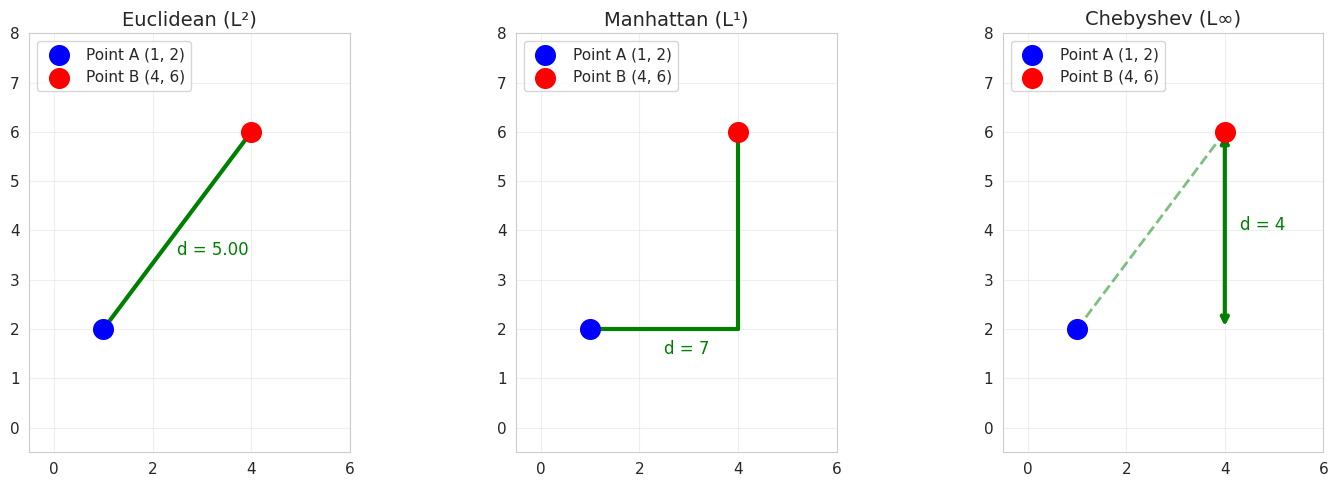

In [23]:
# Visualize the three distance metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Points
point_a = np.array([1, 2])
point_b = np.array([4, 6])

for ax, title in zip(axes, ['Euclidean (L²)', 'Manhattan (L¹)', 'Chebyshev (L∞)']):
    # Plot points
    ax.scatter(*point_a, s=200, c='blue', zorder=5, label='Point A (1, 2)')
    ax.scatter(*point_b, s=200, c='red', zorder=5, label='Point B (4, 6)')
    ax.set_xlim(-0.5, 6)
    ax.set_ylim(-0.5, 8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper left')

# Euclidean: straight line
axes[0].plot([point_a[0], point_b[0]], [point_a[1], point_b[1]], 'g-', linewidth=3)
euclidean = np.sqrt(np.sum((point_a - point_b)**2))
axes[0].text(2.5, 3.5, f'd = {euclidean:.2f}', fontsize=12, color='green')

# Manhattan: city blocks
axes[1].plot([point_a[0], point_b[0]], [point_a[1], point_a[1]], 'g-', linewidth=3)
axes[1].plot([point_b[0], point_b[0]], [point_a[1], point_b[1]], 'g-', linewidth=3)
manhattan = np.sum(np.abs(point_a - point_b))
axes[1].text(2.5, 1.5, f'd = {manhattan:.0f}', fontsize=12, color='green')

# Chebyshev: max dimension
axes[2].plot([point_a[0], point_b[0]], [point_a[1], point_b[1]], 'g--', linewidth=2, alpha=0.5)
# Highlight the max dimension (y difference = 4)
axes[2].annotate('', xy=(4, 6), xytext=(4, 2),
                arrowprops=dict(arrowstyle='<->', color='green', lw=3))
chebyshev = np.max(np.abs(point_a - point_b))
axes[2].text(4.3, 4, f'd = {chebyshev:.0f}', fontsize=12, color='green')

plt.tight_layout()
plt.show()

In [24]:
print("\n📐 Distance Summary for points (1,2) and (4,6):")
print(f"   Euclidean:  {euclidean:.2f}")
print(f"   Manhattan:  {manhattan:.0f}")
print(f"   Chebyshev:  {chebyshev:.0f}")


📐 Distance Summary for points (1,2) and (4,6):
   Euclidean:  5.00
   Manhattan:  7
   Chebyshev:  4


### 3.2 Computing Distances with NumPy

Let's practice computing these distances manually using NumPy. This helps you understand what's happening "under the hood" when k-NN calculates distances.

In [25]:
# Example: Computing distances with NumPy

# Two points in 5-dimensional space
point_a = np.array([1, 2, 3, 4, 5])
point_b = np.array([2, 4, 1, 3, 6])

print("Points:")
print(f"  a = {point_a}")
print(f"  b = {point_b}")
print()

# Step-by-step Euclidean distance
diff = point_a - point_b                  # Element-wise difference
squared_diff = diff ** 2                   # Square each difference
sum_squared = np.sum(squared_diff)         # Sum of squares
euclidean = np.sqrt(sum_squared)           # Square root

print("Euclidean Distance (step by step):")
print(f"  1. Difference: {diff}")
print(f"  2. Squared:    {squared_diff}")
print(f"  3. Sum:        {sum_squared}")
print(f"  4. Sqrt:       {euclidean:.4f}")
print()

# One-liner versions
euclidean_oneliner = np.sqrt(np.sum((point_a - point_b) ** 2))
manhattan_oneliner = np.sum(np.abs(point_a - point_b))
chebyshev_oneliner = np.max(np.abs(point_a - point_b))

print("One-liner calculations:")
print(f"  Euclidean:  np.sqrt(np.sum((a - b) ** 2))    = {euclidean_oneliner:.4f}")
print(f"  Manhattan:  np.sum(np.abs(a - b))           = {manhattan_oneliner}")
print(f"  Chebyshev:  np.max(np.abs(a - b))           = {chebyshev_oneliner}")

Points:
  a = [1 2 3 4 5]
  b = [2 4 1 3 6]

Euclidean Distance (step by step):
  1. Difference: [-1 -2  2  1 -1]
  2. Squared:    [1 4 4 1 1]
  3. Sum:        11
  4. Sqrt:       3.3166

One-liner calculations:
  Euclidean:  np.sqrt(np.sum((a - b) ** 2))    = 3.3166
  Manhattan:  np.sum(np.abs(a - b))           = 7
  Chebyshev:  np.max(np.abs(a - b))           = 2


### 3.3 Using Distance Metrics in scikit-learn

In `KNeighborsClassifier`, specify the metric with the `metric` parameter:

```python
KNeighborsClassifier(n_neighbors=5, metric='euclidean')   # Default
KNeighborsClassifier(n_neighbors=5, metric='manhattan')   # L1
KNeighborsClassifier(n_neighbors=5, metric='chebyshev')   # L∞
```

In [26]:
# Example: Comparing different distance metrics
metrics = ['euclidean', 'manhattan', 'chebyshev']
results = {}

print("Comparing Distance Metrics (k=5):")
print("=" * 40)

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    yhat = knn.predict(X_test)
    acc = accuracy_score(y_test, yhat)
    results[metric] = acc
    print(f"  {metric:12s}: {acc:.4f}")

Comparing Distance Metrics (k=5):
  euclidean   : 0.8562
  manhattan   : 0.8438
  chebyshev   : 0.8375


---

##### **[A3] Experimenting with Distance Metrics** (15 marks)

**Your tasks:**

1. Create three k-NN classifiers, all with `k=5`, each using a different distance metric:
   - `knn_euclidean`: Euclidean distance
   - `knn_manhattan`: Manhattan distance
   - `knn_chebyshev`: Chebyshev distance

2. Train each classifier on `X_train` and `y_train`.

3. Calculate and store the test accuracy for each:
   - `acc_euclidean`
   - `acc_manhattan`
   - `acc_chebyshev`

In [27]:
# Initialize variables
knn_euclidean = None
knn_manhattan = None
knn_chebyshev = None
acc_euclidean = 0
acc_manhattan = 0
acc_chebyshev = 0

*Start student input* ↓

In [28]:
# Complete this.

knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
acc_euclidean = accuracy_score(y_test, knn_euclidean.predict(X_test))

# Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
acc_manhattan = accuracy_score(y_test, knn_manhattan.predict(X_test))

# Chebyshev distance
knn_chebyshev = KNeighborsClassifier(n_neighbors=5, metric='chebyshev')
knn_chebyshev.fit(X_train, y_train)
acc_chebyshev = accuracy_score(y_test, knn_chebyshev.predict(X_test))

*End student input* ↑

In [29]:
print("Results:")
print(f"  Euclidean (L²) Accuracy: {acc_euclidean:.4f}")
print(f"  Manhattan (L¹) Accuracy: {acc_manhattan:.4f}")
print(f"  Chebyshev (L∞) Accuracy: {acc_chebyshev:.4f}")

Results:
  Euclidean (L²) Accuracy: 0.8562
  Manhattan (L¹) Accuracy: 0.8438
  Chebyshev (L∞) Accuracy: 0.8375


VERIFICATION


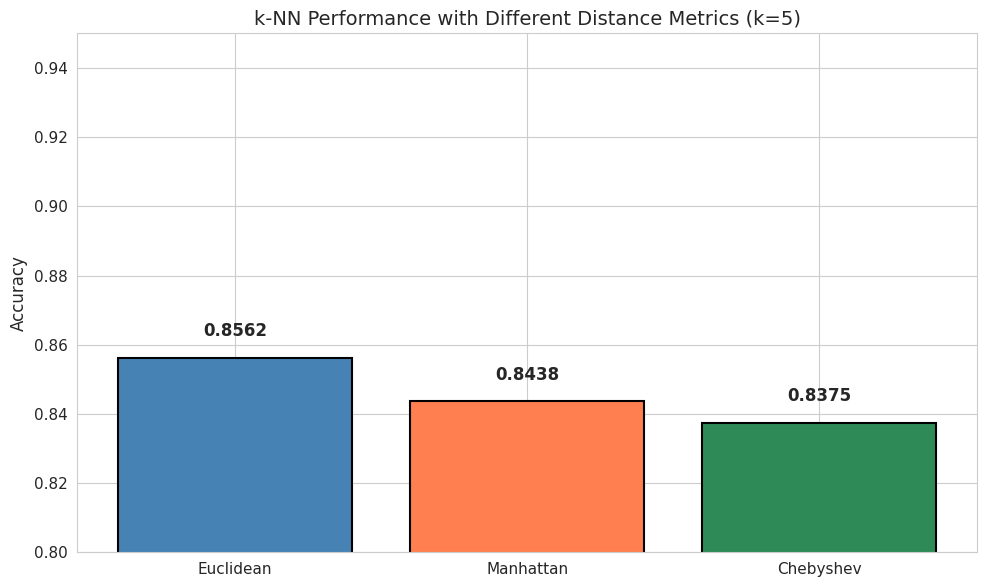


🏆 Best performing metric: Euclidean (0.8562)


In [30]:
# Verification and visualization
print("=" * 50)
print("VERIFICATION")
print("=" * 50)

metric_names = ['Euclidean', 'Manhattan', 'Chebyshev']
accuracies = [acc_euclidean, acc_manhattan, acc_chebyshev]

# Bar chart comparison
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'seagreen']
bars = plt.bar(metric_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0.8, 0.95)
plt.ylabel('Accuracy', fontsize=12)
plt.title('k-NN Performance with Different Distance Metrics (k=5)', fontsize=14)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Find best metric
best_idx = np.argmax(accuracies)
print(f"\n🏆 Best performing metric: {metric_names[best_idx]} ({accuracies[best_idx]:.4f})")

---

## 4. Evaluation Metrics: Beyond Accuracy

Accuracy is intuitive and easy to understand: it's just the percentage of correct predictions. But it can be **dangerously misleading** with imbalanced data.

### 4.1 The Accuracy Paradox

Remember our class distribution?

In [31]:
# The accuracy paradox demonstration
print("Our Test Set Distribution:")
print(f"  Not Good (0): {(y_test == 0).sum()} samples ({100*(y_test == 0).mean():.1f}%)")
print(f"  Good (1):     {(y_test == 1).sum()} samples ({100*(y_test == 1).mean():.1f}%)")

# What if we ALWAYS predict "Not Good"?
always_not_good = np.zeros(len(y_test))  # Predict 0 for everything
naive_accuracy = accuracy_score(y_test, always_not_good)

Our Test Set Distribution:
  Not Good (0): 273 samples (85.3%)
  Good (1):     47 samples (14.7%)


In [32]:
print(f"\n🤔 Thought experiment:")
print(f"   A 'model' that ALWAYS predicts 'Not Good' would achieve:")
print(f"   Accuracy = {naive_accuracy:.4f} ({naive_accuracy*100:.1f}%)")
print(f"\n   But this model is USELESS—it never identifies good wines!")
print(f"   This is why we need metrics beyond accuracy.")


🤔 Thought experiment:
   A 'model' that ALWAYS predicts 'Not Good' would achieve:
   Accuracy = 0.8531 (85.3%)

   But this model is USELESS—it never identifies good wines!
   This is why we need metrics beyond accuracy.


### 4.2 The Confusion Matrix

A confusion matrix breaks down predictions into four categories:

```
                          PREDICTED
                     Negative | Positive
            Negative    TN    |    FP
ACTUAL      ---------+--------+---------
            Positive    FN    |    TP
```

- **True Negative (TN):** Correctly predicted negative ("Not Good" wine correctly identified)
- **True Positive (TP):** Correctly predicted positive ("Good" wine correctly identified)
- **False Positive (FP):** Incorrectly predicted positive ("Not Good" wine wrongly called "Good") — **Type I Error**
- **False Negative (FN):** Incorrectly predicted negative ("Good" wine wrongly called "Not Good") — **Type II Error**

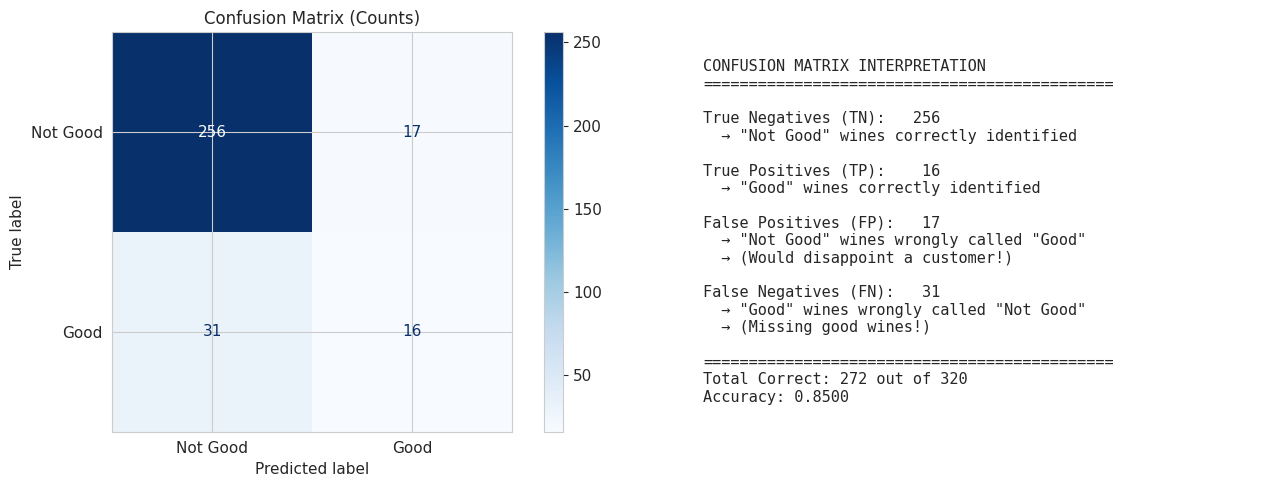

In [33]:
# Create and visualize confusion matrix for our baseline model
cm_baseline = confusion_matrix(y_test, yhat_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_baseline,
                               display_labels=['Not Good', 'Good'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12)

# Annotated interpretation
axes[1].axis('off')
tn, fp, fn, tp = cm_baseline.ravel()

interpretation = f"""
CONFUSION MATRIX INTERPRETATION
{'='*45}

True Negatives (TN):  {tn:4d}
  → "Not Good" wines correctly identified

True Positives (TP):  {tp:4d}
  → "Good" wines correctly identified

False Positives (FP): {fp:4d}
  → "Not Good" wines wrongly called "Good"
  → (Would disappoint a customer!)

False Negatives (FN): {fn:4d}
  → "Good" wines wrongly called "Not Good"
  → (Missing good wines!)

{'='*45}
Total Correct: {tn + tp} out of {len(y_test)}
Accuracy: {(tn + tp) / len(y_test):.4f}
"""
axes[1].text(0.1, 0.5, interpretation, fontsize=11, family='monospace',
             verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

### 4.3 Precision, Recall, and F1 Score

These metrics focus on the **positive class** (in our case, "Good" wines).

#### Precision
"Of all the wines I predicted as Good, how many were actually Good?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

**High precision** means few false positives. Important when **false positives are costly**:
- Spam filter: Don't want important emails marked as spam
- Legal: Don't want innocent people convicted

#### Recall (Sensitivity)
"Of all the wines that were actually Good, how many did I correctly identify?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

**High recall** means few false negatives. Important when **missing positives is costly**:
- Disease screening: Don't want to miss cancer patients
- Security: Don't want to miss threats

#### F1 Score
The harmonic mean of precision and recall—balances both:

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Why harmonic mean?** It penalizes extreme imbalances. If precision=1.0 but recall=0.01, the F1 score will be low (~0.02), not the average (0.505).

In [34]:
# Calculate all metrics for our baseline model
precision_base = precision_score(y_test, yhat_baseline)
recall_base = recall_score(y_test, yhat_baseline)
f1_base = f1_score(y_test, yhat_baseline)

print("Baseline Model Evaluation Metrics:")
print("=" * 45)
print(f"  Accuracy:  {accuracy_baseline:.4f}  (Overall correctness)")
print(f"  Precision: {precision_base:.4f}  (Of predicted Good, how many correct?)")
print(f"  Recall:    {recall_base:.4f}  (Of actual Good, how many found?)")
print(f"  F1 Score:  {f1_base:.4f}  (Balance of precision and recall)")
print("=" * 45)

if recall_base < 0.5:
    print("\n⚠️ OBSERVATION: Recall is quite low!")
    print("   The model is missing many 'Good' wines.")
    print("   This is common with imbalanced data.")

Baseline Model Evaluation Metrics:
  Accuracy:  0.8500  (Overall correctness)
  Precision: 0.4848  (Of predicted Good, how many correct?)
  Recall:    0.3404  (Of actual Good, how many found?)
  F1 Score:  0.4000  (Balance of precision and recall)

⚠️ OBSERVATION: Recall is quite low!
   The model is missing many 'Good' wines.
   This is common with imbalanced data.


### 4.4 Visualizing the Metrics

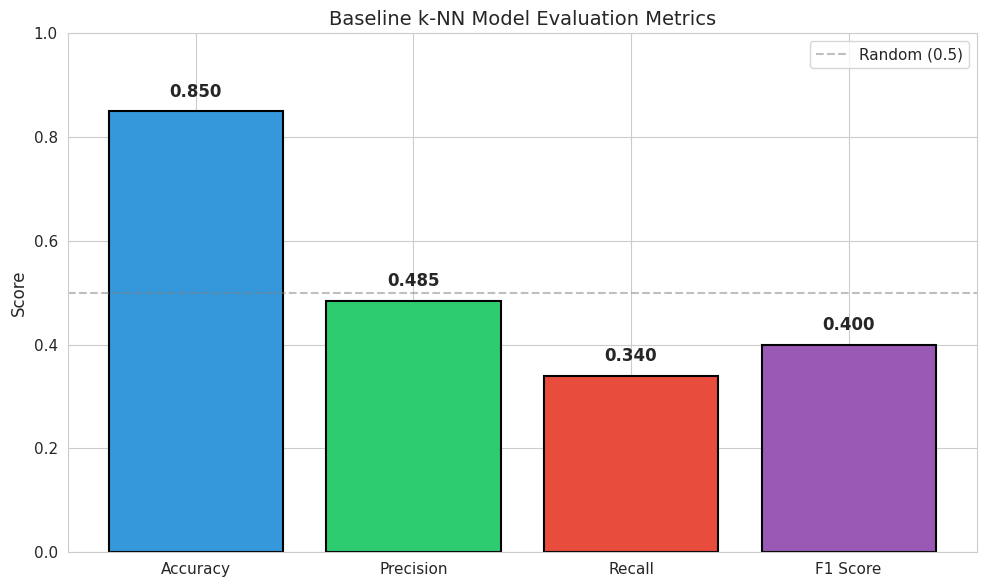

In [35]:
# Visual comparison of metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy_baseline, precision_base, recall_base, f1_base]

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = plt.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0, 1.0)
plt.ylabel('Score', fontsize=12)
plt.title('Baseline k-NN Model Evaluation Metrics', fontsize=14)

# Add value labels
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add reference line at 0.5
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
plt.legend()

plt.tight_layout()
plt.show()

---

##### **[A4] Evaluation Metrics** (25 marks)

**Your tasks:**

1. Using your best-performing distance metric from Activity 3, create a new k-NN classifier with `k=7` named `knn_eval`.

2. Train it and make predictions on the test set. Store predictions as `yhat_eval`.

3. Calculate and store:
   - `cm_eval`: Confusion matrix
   - `precision_eval`: Precision score
   - `recall_eval`: Recall score
   - `f1_eval`: F1 score
   - `accuracy_eval`: Accuracy score

4. Display the confusion matrix using `ConfusionMatrixDisplay`.

In [36]:
# Initialize variables
knn_eval = None
yhat_eval = None
cm_eval = None
precision_eval = 0
recall_eval = 0
f1_eval = 0
accuracy_eval = 0

*Start student input* ↓

In [37]:
# Complete this.

metric_accuracies = {
    'euclidean': acc_euclidean,
    'manhattan': acc_manhattan,
    'chebyshev': acc_chebyshev
}
best_metric = max(metric_accuracies, key=metric_accuracies.get)
print(f"Best-performing metric from Activity 3: {best_metric} ({metric_accuracies[best_metric]:.4f})")

# Build, train, and evaluate the k=7 model
knn_eval = KNeighborsClassifier(n_neighbors=7, metric=best_metric)
knn_eval.fit(X_train, y_train)
yhat_eval = knn_eval.predict(X_test)

cm_eval = confusion_matrix(y_test, yhat_eval)
precision_eval = precision_score(y_test, yhat_eval)
recall_eval = recall_score(y_test, yhat_eval)
f1_eval = f1_score(y_test, yhat_eval)
accuracy_eval = accuracy_score(y_test, yhat_eval)

Best-performing metric from Activity 3: euclidean (0.8562)


*End student input* ↑

In [38]:
print("Evaluation Metrics (k=7):")
print("=" * 40)
print(f"  Accuracy:  {accuracy_eval:.4f}")
print(f"  Precision: {precision_eval:.4f}")
print(f"  Recall:    {recall_eval:.4f}")
print(f"  F1 Score:  {f1_eval:.4f}")

Evaluation Metrics (k=7):
  Accuracy:  0.8406
  Precision: 0.3571
  Recall:    0.1064
  F1 Score:  0.1639


*Start student input* ↓

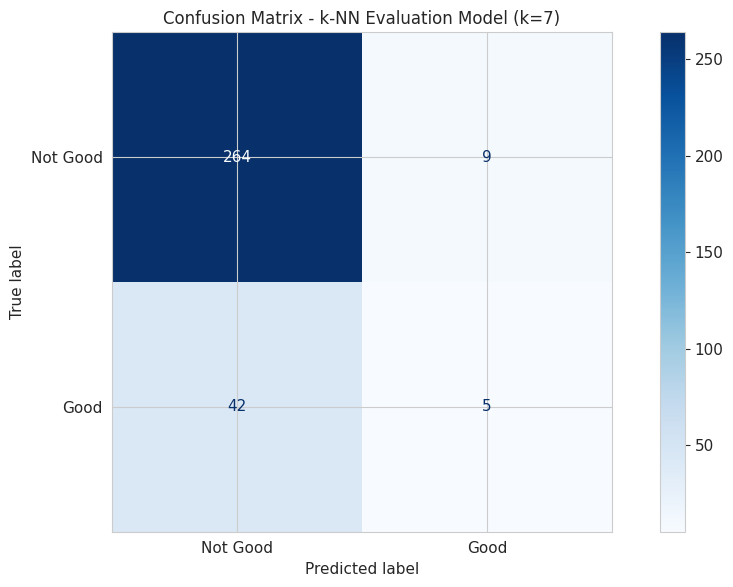

In [39]:
# 4. Display the confusion matrix

disp_eval = ConfusionMatrixDisplay(confusion_matrix=cm_eval, display_labels=['Not Good', 'Good'])
disp_eval.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - k-NN Evaluation Model (k=7)', fontsize=12)
plt.tight_layout()
plt.show()

*End student input* ↑

In [40]:
# Verification
print("=" * 50)
print("VERIFICATION")
print("=" * 50)
print(f"Confusion matrix shape: {cm_eval.shape if cm_eval is not None else 'Not set'}")
print(f"CM sum: {cm_eval.sum() if cm_eval is not None else 'Not set'} (should = {len(y_test)})")
tn, fp, fn, tp = cm_eval.ravel() if cm_eval is not None else (0, 0, 0, 0)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

VERIFICATION
Confusion matrix shape: (2, 2)
CM sum: 320 (should = 320)
TN=264, FP=9, FN=42, TP=5


---

## 5. Hyperparameter Tuning and Generalization

The value of $k$ in k-NN is a **hyperparameter**—a setting we choose before training that controls the model's behavior. Choosing the right $k$ is crucial for achieving good **generalization**.

### 5.1 The Bias-Variance Tradeoff

In machine learning, there's a fundamental tension:

| Problem | Description | k-NN Manifestation | Symptom |
|---------|-------------|-------------------|--------|
| **High Variance (Overfitting)** | Model is too complex, fits noise | **Small k** (e.g., k=1) | High training accuracy, low test accuracy |
| **High Bias (Underfitting)** | Model is too simple, misses patterns | **Large k** (e.g., k=100) | Low accuracy on both training and test |

**At k=1:** The model memorizes the training data. Every training point is its own nearest neighbor, so training accuracy is 100%! But new points might be influenced by noise.

**At very large k:** The model becomes too "smooth"—every prediction approaches the majority class. It underfits.

In [41]:
# Demonstrate overfitting at k=1
knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_train, y_train)

train_acc_k1 = accuracy_score(y_train, knn_k1.predict(X_train))
test_acc_k1 = accuracy_score(y_test, knn_k1.predict(X_test))

print("Overfitting Demonstration (k=1):")
print("=" * 45)
print(f"  Training Accuracy: {train_acc_k1:.4f} (100% - perfect memorization!)")
print(f"  Test Accuracy:     {test_acc_k1:.4f} (lower on unseen data)")
print(f"  Gap:               {train_acc_k1 - test_acc_k1:.4f}")
print("\n⚠️ This gap indicates OVERFITTING!")
print("   The model memorized training data but doesn't generalize.")

Overfitting Demonstration (k=1):
  Training Accuracy: 1.0000 (100% - perfect memorization!)
  Test Accuracy:     0.8531 (lower on unseen data)
  Gap:               0.1469

⚠️ This gap indicates OVERFITTING!
   The model memorized training data but doesn't generalize.


### 5.2 The Validation Loop

To find the optimal $k$, we systematically try many values and compare their performance:

```python
for k in range(1, max_k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    train_score = evaluate(model, X_train, y_train)
    test_score = evaluate(model, X_test, y_test)
    
    store_results(k, train_score, test_score)
```

By plotting both training and test performance, we can **visualize the overfitting-underfitting tradeoff**.

In [42]:
# Comprehensive validation loop
k_values = range(1, 51)
train_accuracies = []
test_accuracies = []

print("Running validation loop for k = 1 to 50...")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

print("Done!")

Running validation loop for k = 1 to 50...
Done!


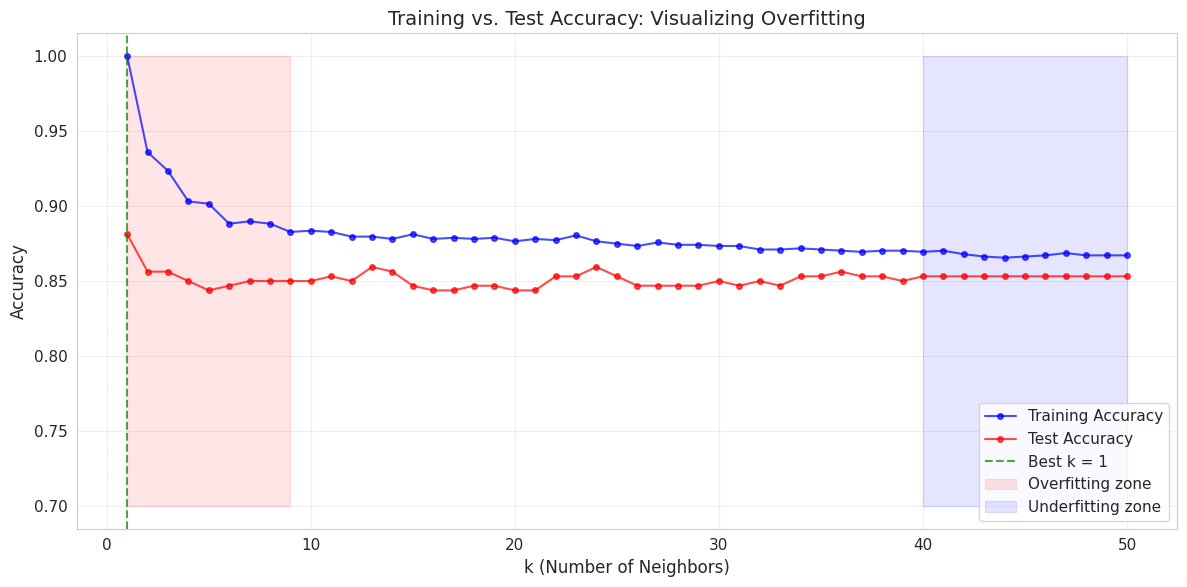

In [43]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, 'b-o', label='Training Accuracy', markersize=4, alpha=0.7)
plt.plot(k_values, test_accuracies, 'r-o', label='Test Accuracy', markersize=4, alpha=0.7)

# Find best k
best_k = k_values[np.argmax(test_accuracies)]
best_test_acc = max(test_accuracies)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best k = {best_k}')

# Annotations
plt.fill_between(range(1, 10), 0.7, 1.0, alpha=0.1, color='red', label='Overfitting zone')
plt.fill_between(range(40, 51), 0.7, 1.0, alpha=0.1, color='blue', label='Underfitting zone')

plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs. Test Accuracy: Visualizing Overfitting', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
print(f"\n🎯 Best k = {best_k} with test accuracy = {best_test_acc:.4f}")
print(f"   Training accuracy at k=1: {train_accuracies[0]:.4f} (overfitting!)")
print(f"   Test accuracy at k=1: {test_accuracies[0]:.4f}")


🎯 Best k = 1 with test accuracy = 0.8812
   Training accuracy at k=1: 1.0000 (overfitting!)
   Test accuracy at k=1: 0.8812


---

##### **[A5] Hyperparameter Tuning and Generalization** (25 marks)

**Your tasks:**

1. Create a validation loop that tests k values from 1 to 25. For each k:
   - Train a k-NN model with **Manhattan distance**
   - Calculate both training and test **F1 scores** (not accuracy!)
   - Store them in `train_f1_scores` and `test_f1_scores`

2. Find the value of k that gives the highest **test** F1 score. Store it in `best_k_f1`.

3. Store the best F1 score in `best_f1_score`.

4. Create a plot showing both training and test F1 scores vs. k. Mark the best k with a vertical line.

In [45]:
# Initialize variables
k_range = range(1, 26)  # k from 1 to 25
train_f1_scores = []
test_f1_scores = []
best_k_f1 = 0
best_f1_score = 0

*Start student input* ↓

In [46]:
# Complete this.

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_train, y_train)

    train_f1 = f1_score(y_train, knn.predict(X_train))
    test_f1 = f1_score(y_test, knn.predict(X_test))

    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

# Find the k with the best test F1 score
best_k_f1 = list(k_range)[np.argmax(test_f1_scores)]
best_f1_score = max(test_f1_scores)

*End student input* ↑

In [47]:
print(f"Best k (by F1 score): {best_k_f1}")
print(f"Best Test F1 Score:   {best_f1_score:.4f}")

Best k (by F1 score): 1
Best Test F1 Score:   0.5957


*Start student input* ↓

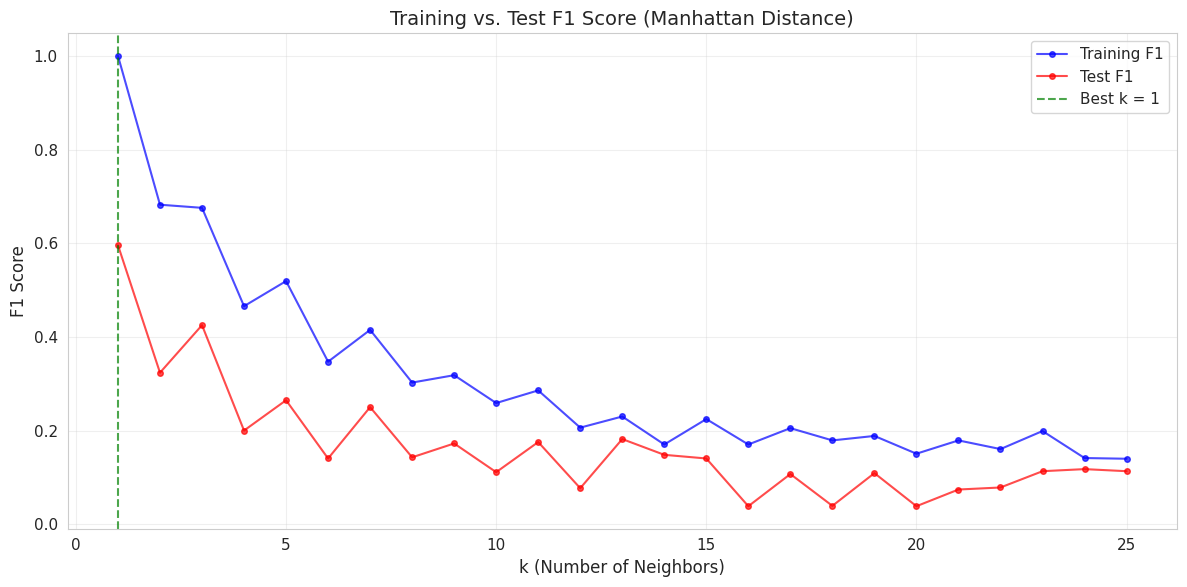

In [48]:
# 4. Create the plot

plt.figure(figsize=(12, 6))
plt.plot(list(k_range), train_f1_scores, 'b-o', label='Training F1', markersize=4, alpha=0.7)
plt.plot(list(k_range), test_f1_scores, 'r-o', label='Test F1', markersize=4, alpha=0.7)
plt.axvline(x=best_k_f1, color='green', linestyle='--', alpha=0.7, label=f'Best k = {best_k_f1}')

plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Training vs. Test F1 Score (Manhattan Distance)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*End student input* ↑

In [49]:
# Verification
print("=" * 50)
print("VERIFICATION")
print("=" * 50)
print(f"Number of k values tested: {len(train_f1_scores)}")
print(f"Best k: {best_k_f1}")
print(f"Best test F1: {best_f1_score:.4f}")
print(f"\nOverfitting indicators:")
print(f"  Train F1 at k=1: {train_f1_scores[0]:.4f}")
print(f"  Test F1 at k=1:  {test_f1_scores[0]:.4f}")
print(f"  Gap at k=1:      {train_f1_scores[0] - test_f1_scores[0]:.4f}")

VERIFICATION
Number of k values tested: 25
Best k: 1
Best test F1: 0.5957

Overfitting indicators:
  Train F1 at k=1: 1.0000
  Test F1 at k=1:  0.5957
  Gap at k=1:      0.4043


---

## 6. The Problem with Raw Features

Throughout this lab, we've been using **unnormalized features**—the raw values straight from the dataset. Let's investigate what this means for our k-NN classifier.

In [50]:
# Analyze feature scales
feature_stats = pd.DataFrame({
    'Min': X.min(),
    'Max': X.max(),
    'Range': X.max() - X.min(),
    'Mean': X.mean(),
    'Std': X.std()
}).round(3)

print("Feature Scale Analysis:")
print("=" * 70)
print(feature_stats.sort_values('Range', ascending=False))

print("\n⚠️ SCALE IMBALANCE:")
print(f"   Largest range:  {feature_stats['Range'].max():.1f} (total sulfur dioxide)")
print(f"   Smallest range: {feature_stats['Range'].min():.4f} (density)")
print(f"   Ratio: {feature_stats['Range'].max() / feature_stats['Range'].min():.0f}x difference!")

Feature Scale Analysis:
                        Min      Max    Range    Mean     Std
total sulfur dioxide  6.000  289.000  283.000  46.468  32.895
free sulfur dioxide   1.000   72.000   71.000  15.875  10.460
residual sugar        0.900   15.500   14.600   2.539   1.410
fixed acidity         4.600   15.900   11.300   8.320   1.741
alcohol               8.400   14.900    6.500  10.423   1.066
sulphates             0.330    2.000    1.670   0.658   0.170
volatile acidity      0.120    1.580    1.460   0.528   0.179
pH                    2.740    4.010    1.270   3.311   0.154
citric acid           0.000    1.000    1.000   0.271   0.195
chlorides             0.012    0.611    0.599   0.087   0.047
density               0.990    1.004    0.014   0.997   0.002

⚠️ SCALE IMBALANCE:
   Largest range:  283.0 (total sulfur dioxide)
   Smallest range: 0.0140 (density)
   Ratio: 20214x difference!


In [51]:
# Demonstrate how features contribute to distance
np.random.seed(42)
idx1, idx2 = np.random.choice(len(X), 2, replace=False)
point1 = X.iloc[idx1].values
point2 = X.iloc[idx2].values

# Calculate contributions
squared_diffs = (point1 - point2) ** 2
total_squared_dist = squared_diffs.sum()

contributions = pd.DataFrame({
    'Feature': X.columns,
    'Point 1': point1,
    'Point 2': point2,
    'Squared Diff': squared_diffs,
    '% of Total Distance': 100 * squared_diffs / total_squared_dist
}).sort_values('% of Total Distance', ascending=False)

print("Feature Contributions to Euclidean Distance (Two Random Points):")
print("=" * 75)
print(contributions.to_string(index=False))
print("=" * 75)
print(f"Total Euclidean distance: {np.sqrt(total_squared_dist):.2f}")

Feature Contributions to Euclidean Distance (Two Random Points):
             Feature  Point 1  Point 2  Squared Diff  % of Total Distance
total sulfur dioxide  46.0000  102.000   3136.000000         9.843380e+01
 free sulfur dioxide  14.0000   21.000     49.000000         1.538028e+00
      residual sugar   2.5000    1.600      0.810000         2.542455e-02
           sulphates   0.6600    0.480      0.032400         1.016982e-03
                  pH   3.2400    3.390      0.022500         7.062374e-04
       fixed acidity   7.7000    7.800      0.010000         3.138833e-04
             alcohol   9.6000    9.500      0.010000         3.138833e-04
         citric acid   0.0800    0.170      0.008100         2.542455e-04
    volatile acidity   0.5600    0.500      0.003600         1.129980e-04
           chlorides   0.1140    0.082      0.001024         3.214165e-05
             density   0.9971    0.996      0.000001         3.797988e-08
Total Euclidean distance: 56.44


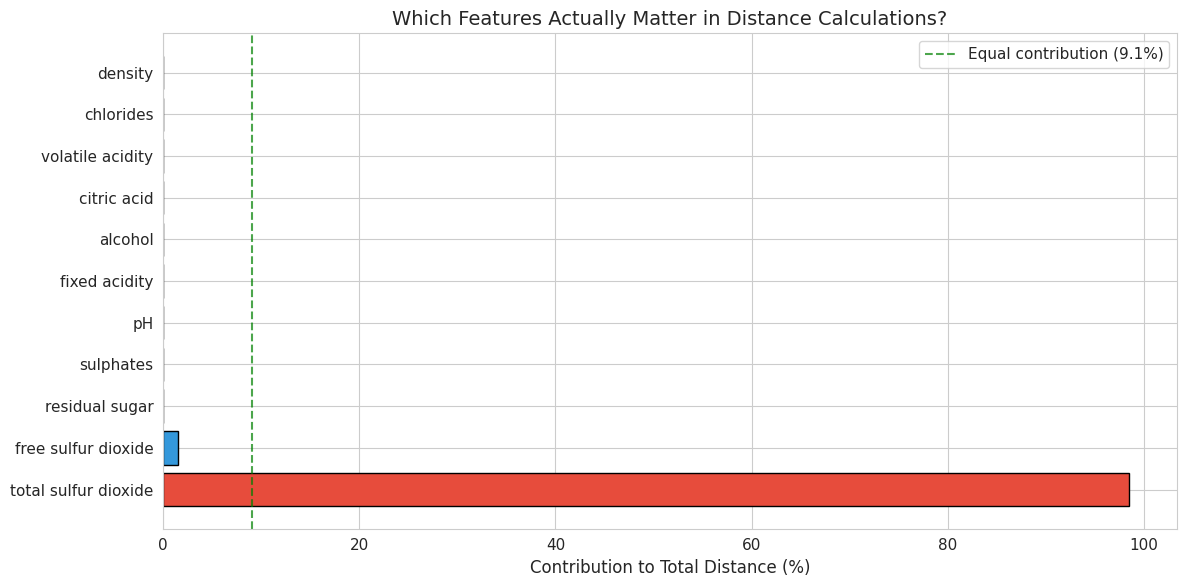

In [52]:
# Visualize
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if p > 10 else '#3498db' if p > 1 else '#95a5a6'
          for p in contributions['% of Total Distance']]
plt.barh(contributions['Feature'], contributions['% of Total Distance'], color=colors, edgecolor='black')
plt.xlabel('Contribution to Total Distance (%)', fontsize=12)
plt.title('Which Features Actually Matter in Distance Calculations?', fontsize=14)
plt.axvline(x=100/11, color='green', linestyle='--', alpha=0.7, label='Equal contribution (9.1%)')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
print("\n🔍 KEY INSIGHT:")
print("   Features with large numerical ranges DOMINATE the distance calculation.")
print("   Features with small ranges are essentially IGNORED.")
print("   This might not reflect their actual IMPORTANCE for prediction!")


🔍 KEY INSIGHT:
   Features with large numerical ranges DOMINATE the distance calculation.
   Features with small ranges are essentially IGNORED.
   This might not reflect their actual IMPORTANCE for prediction!


---

##### **[A6] Discussion Questions** (20 marks)

Answer the following questions based on your work in this lab. Write thoughtful, complete answers.

(5 marks) Looking at your plot from Activity 5:
- At what value(s) of k does the model appear to be **overfitting**?
- How can you tell from the plot that overfitting is occurring?
- Why does k=1 always achieve 100% training accuracy (or very close to it)?

*Start student input* ↓

Overfitting is visible at the small end of the k range, roughly k = 1 through k = 3–5, where the training F1 curve sits well above the test F1 curve. The size of that gap is the tell: a model that fits the training data almost perfectly but scores noticeably lower on the held-out test set has learned the training points themselves rather than the underlying pattern. As k grows, the two curves converge, which is that gap closing as the model relies less on any single point.

k=1 achieves (or comes very close to) 100% training accuracy because, when the model is evaluated on the training set itself, each training point's single nearest neighbor is itself (distance = 0), so it always predicts its own label correctly. This is exactly the "memorization" the lab describes — the model isn't generalizing, it's just recalling.

*End student input* ↑

(5 marks) Why did we use **F1 score** instead of accuracy for hyperparameter tuning in Activity 5? What specific problem does F1 score help address with this dataset?

*Start student input* ↓

The dataset is imbalanced,  only a small fraction of wines are labeled "Good" (quality ≥ 7). Accuracy doesn't penalize a model for ignoring the minority class: a model that predicts "Not Good" for everything still scores high accuracy simply because most wines really are "Not Good." That makes accuracy a poor signal for choosing k here, since it would reward a k that never finds any good wines.

F1 score is the harmonic mean of precision and recall for the positive ("Good") class, so it only stays high if the model both catches good wines (recall) and doesn't over-flag mediocre ones as good (precision). Tuning on F1 instead of accuracy steers the search toward a k that actually performs on the class we care about, rather than one that gets a "free ride" from the majority class.

*End student input* ↑

(5 marks) Based on the feature contribution analysis in Section 6:
- Which feature(s) are dominating the distance calculation?
- Which feature(s) are being essentially ignored?
- Why is this potentially problematic for our k-NN classifier?

*Start student input* ↓

Features with the largest raw numerical ranges, total sulfur dioxide and free sulfur dioxide in particular, dominate the Euclidean distance calculation, since large differences squared inflate the total distance disproportionately to their actual importance. Features measured on much smaller scales, such as density, chlorides, and pH, contribute almost nothing to the distance even though their values vary meaningfully within their own range.

This is a problem for k-NN because "nearness" is supposed to reflect overall similarity between wines, but in practice the model ends up measuring similarity mostly along whichever one or two features happen to have the largest raw numbers. A feature with real predictive power for quality can become functionally invisible to the model just because of the units it happens to be recorded in.

*End student input* ↑

(5 marks) Propose a solution to the feature scale problem you identified. Describe the general approach (you don't need to implement it) and explain how it would change the distance calculations.

*Start student input* ↓

The fix is feature scaling (normalization), applied to every feature before any distances are computed. Two common approaches: standardization (subtract each feature's mean and divide by its standard deviation, so every feature ends up with mean 0 and standard deviation 1), or min-max scaling (rescale each feature into a fixed range, typically [0, 1]).

Once every feature sits on a comparable scale, no single feature can dominate the distance calculation purely because of the units it happens to be measured in. Differences between points would instead reflect how unusual or typical each point is relative to that feature's own spread, so a wine's chloride level and its total sulfur dioxide level would each get a fair say in how "close" it is to another wine — bringing k-NN's notion of similarity in line with the actual chemistry rather than the accident of measurement units.

*End student input* ↑

---

## Lab Summary

Congratulations on completing this lab! Here's what you've learned:

### Technical Skills

1. **Working with Real Data**: You downloaded and explored a dataset from Kaggle, performed EDA, and handled class imbalance.

2. **Distance Metrics**: You implemented and compared Euclidean, Manhattan, and Chebyshev distances, understanding how each measures "similarity" differently.

3. **Evaluation Beyond Accuracy**: You learned to use precision, recall, F1 score, and confusion matrices—essential tools for imbalanced classification problems.

4. **Hyperparameter Tuning**: You systematically searched for the optimal k using validation loops and visualized the results.

5. **Understanding Generalization**: You observed overfitting in action and learned to diagnose it by comparing training vs. test performance.

### Key Takeaways

| Concept | Key Insight |
|---------|-------------|
| **Overfitting** | Small k → memorization → poor generalization |
| **Underfitting** | Large k → over-smoothing → misses patterns |
| **Class Imbalance** | Accuracy can be misleading; use F1, precision, recall |
| **Feature Scales** | Unnormalized features can bias distance calculations |
| **The Sweet Spot** | Good ML = finding the balance that generalizes well |

### Looking Ahead

In the next unit, you'll learn about **feature normalization**—the solution to the scale problem we identified. You'll see how preprocessing can dramatically improve model performance!

### Portfolio Reminder

This lab demonstrates skills that employers value:
- Working with real-world data from Kaggle
- Proper model evaluation methodology
- Understanding of fundamental ML concepts

Consider cleaning up your code and publishing a version on Kaggle Notebooks or GitHub!